# model output

This notebook demonstrates the model output workflow in PyHydroGeophysX.


In [1]:
import os
import sys
import numpy as np
import matplotlib.pyplot as plt

# Setup package path for development
try:
    # For regular Python scripts
    current_dir = os.path.dirname(os.path.abspath(__file__))
except NameError:
    # For Jupyter notebooks
    current_dir = os.getcwd()

# Add the parent directory to Python path
parent_dir = os.path.dirname(current_dir)
if parent_dir not in sys.path:
    sys.path.append(parent_dir)

# Import PyHydroGeophysX modules
from PyHydroGeophysX.model_output.parflow_output import ParflowSaturation, ParflowPorosity
from PyHydroGeophysX.model_output.modflow_output import MODFLOWWaterContent, MODFLOWPorosity

c:\Users\hchen117\OneDrive - University of Iowa\Documents\GitHub\PyHydroGeophysX\PyHydroGeophysX\__init__.py:15: FutureWarning: Importing `SimPEG` is deprecated. please import from `simpeg`.
  import SimPEG as _simpeg


API path =  c:\Users\hchen117\.conda\envs\pg\lib\site-packages\resipy
ResIPy version =  3.5.4
cR2.exe found and up to date.
R3t.exe found and up to date.
cR3t.exe found and up to date.
[PyHydroGeophysX] RESIPY loaded successfully
[PyHydroGeophysX] PyGIMLi loaded successfully
[PyHydroGeophysX] SimPEG loaded successfully (version 0.24.0)


c:\Users\hchen117\.conda\envs\pg\lib\site-packages\resipy\meshTools.py:56: UserWarning: pyvista not installed, 3D meshing viewing options will be limited
  warnings.warn('pyvista not installed, 3D meshing viewing options will be limited')


## 1. Parflow example

In [2]:


# Load saturation data
saturation_processor = ParflowSaturation(
    model_directory="./data/parflow/test2",
    run_name="test2"
)
saturation = saturation_processor.load_timestep(200)  # Load first timestep

# Load porosity data
porosity_processor = ParflowPorosity(
    model_directory="./data/parflow/test2",
    run_name="test2"
)
porosity = porosity_processor.load_porosity()

mask = porosity_processor.load_mask()
mask.shape
porosity[mask==0] = np.nan
saturation[mask==0] = np.nan

(20, 50, 48)


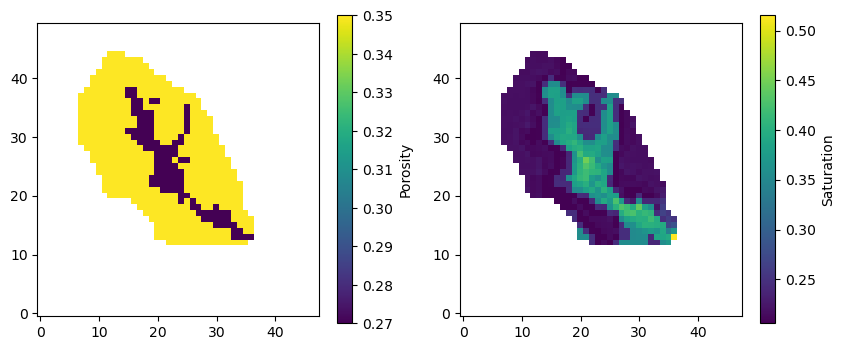

In [3]:
print(saturation.shape)
# Plotting the data
plt.figure(figsize=(10, 4))
plt.subplot(1, 2, 1)
plt.imshow(porosity[19, :, :], cmap='viridis')
plt.colorbar(label='Porosity')
plt.gca().invert_yaxis()
plt.subplot(1, 2, 2)
plt.imshow(saturation[19, :, :], cmap='viridis')
plt.colorbar(label='Saturation')
plt.gca().invert_yaxis()

## 2. MODFLOW example

## These would be your actual data files


In [4]:
# These would be your actual data files
data_dir = "data/"
modflow_dir = os.path.join(data_dir, "modflow")
idomain = np.loadtxt(os.path.join(modflow_dir, "id.txt"))

# Initialize MODFLOW water content processor
water_content_processor = MODFLOWWaterContent(
    model_directory=modflow_dir,  # Changed from sim_ws
    idomain=idomain
)

# Load water content for a specific timestep
timestep = 1
water_content = water_content_processor.load_timestep(timestep)

print(water_content.shape)


# Path to your MODFLOW model directory

model_name = "TLnewtest2sfb2"  # Your model name

# 1. Create an instance of the MODFLOWPorosity class
porosity_loader = MODFLOWPorosity(
    model_directory=modflow_dir,
    model_name=model_name
)
# 2. Load the porosity data
porosity_data = porosity_loader.load_porosity()

c:\Users\hchen117\OneDrive - University of Iowa\Documents\GitHub\PyHydroGeophysX\PyHydroGeophysX\model_output\modflow_output.py:169: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  WC_arr[k, i, j] = np.array(binaryread(file, vartype).tolist())


(3, 37, 31)


## Plotting the data


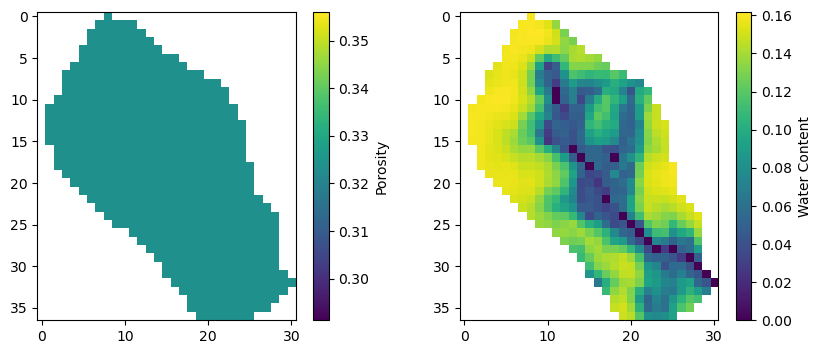

In [5]:
# Plotting the data


porosity_data1 = porosity_data[0, :, :]
porosity_data1[idomain==0] = np.nan

plt.figure(figsize=(10, 4))
plt.subplot(1, 2, 1)
plt.imshow(porosity_data1[ :, :], cmap='viridis')
plt.colorbar(label='Porosity')

plt.subplot(1, 2, 2)
plt.imshow(water_content[0, :, :], cmap='viridis')
plt.colorbar(label='Water Content')
